# [FAST] Notebook 02 — Analisis Inference Time & Throughput
Data dari **Table 3** jurnal Oprea & Bâra (2026).  



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

FIGURES = Path('../outputs/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

df = pd.read_csv('../dataset/table3_timing_metrics.csv')
print("=== TABLE 3: Timing Metrics (exact dari jurnal) ===")
print(df[['GPU','Model','Precision','Time_s','Tokens_per_s','Note']].to_string(index=False))

=== TABLE 3: Timing Metrics (exact dari jurnal) ===
    GPU             Model Precision  Time_s  Tokens_per_s                           Note
RTX4070             GPT-2      FP16   23.21         11.03           Normal GPU inference
RTX4070             GPT-2      INT8   17.37         14.74           Normal GPU inference
RTX4080             GPT-2      FP16    1.10        231.73           Normal GPU inference
RTX4080             GPT-2      INT8    2.01        127.36           Normal GPU inference
RTX4070   LLaMA-2-7B-Chat      FP16 1244.29          0.21 CPU offloading (VRAM exceeded)
RTX4070   LLaMA-2-7B-Chat      INT8   18.63         13.74           Normal GPU inference
RTX4080   LLaMA-2-7B-Chat      FP16   50.04          5.12           Normal GPU inference
RTX4080   LLaMA-2-7B-Chat      INT8   26.64          9.61           Normal GPU inference
RTX4070 Qwen1.5-1.8B-Chat      FP16   12.66         20.22           Normal GPU inference
RTX4070 Qwen1.5-1.8B-Chat      INT8   11.78         21.73 

## 1. Hitung speedup tiap konfigurasi

In [2]:
rows = []
for (gpu, model), grp in df.groupby(['GPU','Model']):
    fp16 = grp[grp.Precision=='FP16']['Time_s'].values[0]
    int8 = grp[grp.Precision=='INT8']['Time_s'].values[0]
    tps_fp16 = grp[grp.Precision=='FP16']['Tokens_per_s'].values[0]
    tps_int8 = grp[grp.Precision=='INT8']['Tokens_per_s'].values[0]
    speedup  = round(fp16 / int8, 2)
    rows.append({
        'GPU': gpu, 'Model': model,
        'FP16 (s)': fp16, 'INT8 (s)': int8,
        'Speedup': speedup,
        'Tok/s FP16': tps_fp16, 'Tok/s INT8': tps_int8,
        'Status': '[WARNING] CPU offload' if speedup > 30 else ('🔴 INT8 lebih lambat' if speedup < 1 else '[OK] INT8 lebih cepat')
    })

spd = pd.DataFrame(rows)
print("=== Tabel Speedup (FP16 → INT8) ===")
print(spd.to_string(index=False))
print()
print("📌 Temuan penting jurnal:")
print(f"  • Speedup TERBESAR : LLaMA-2 RTX4070 = {spd.Speedup.max()}x (karena CPU offloading FP16)")
print(f"  • Speedup TERKECIL : {spd.loc[spd.Speedup.idxmin(),'Model']} {spd.loc[spd.Speedup.idxmin(),'GPU']} = {spd.Speedup.min()}x")
print(f"  • GPT-2 INT8 RTX4080 LEBIH LAMBAT dari FP16 (overhead kernel launch)")
print(f"  • Rata-rata speedup jurnal = 3.4x (excl. CPU offload)")

=== Tabel Speedup (FP16 → INT8) ===
    GPU             Model  FP16 (s)  INT8 (s)  Speedup  Tok/s FP16  Tok/s INT8                Status
RTX4070             GPT-2     23.21     17.37     1.34       11.03       14.74 [OK] INT8 lebih cepat
RTX4070   LLaMA-2-7B-Chat   1244.29     18.63    66.79        0.21       13.74 [WARNING] CPU offload
RTX4070 Qwen1.5-1.8B-Chat     12.66     11.78     1.07       20.22       21.73 [OK] INT8 lebih cepat
RTX4080             GPT-2      1.10      2.01     0.55      231.73      127.36   🔴 INT8 lebih lambat
RTX4080   LLaMA-2-7B-Chat     50.04     26.64     1.88        5.12        9.61 [OK] INT8 lebih cepat
RTX4080 Qwen1.5-1.8B-Chat     13.61     11.08     1.23       18.81       23.10 [OK] INT8 lebih cepat

📌 Temuan penting jurnal:
  • Speedup TERBESAR : LLaMA-2 RTX4070 = 66.79x (karena CPU offloading FP16)
  • Speedup TERKECIL : GPT-2 RTX4080 = 0.55x
  • GPT-2 INT8 RTX4080 LEBIH LAMBAT dari FP16 (overhead kernel launch)
  • Rata-rata speedup jurnal = 3.4x (e

## 2. Reproduksi Figure 2 — Inference Time RTX4070

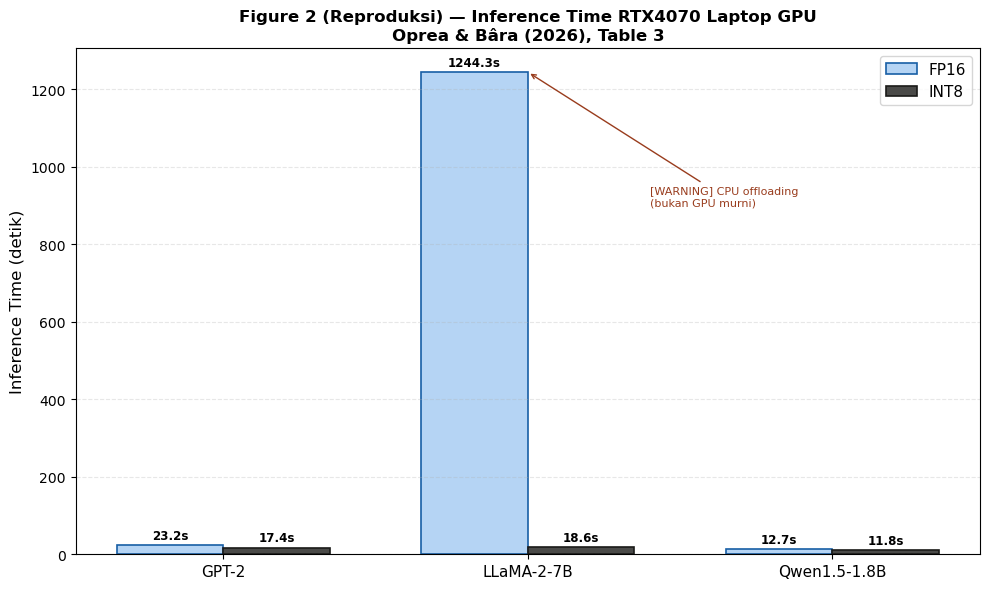

[OK] Disimpan: outputs/figures/fig2_rtx4070_inference.png


In [3]:
models  = ['GPT-2','LLaMA-2-7B-Chat','Qwen1.5-1.8B-Chat']
labels  = ['GPT-2','LLaMA-2-7B','Qwen1.5-1.8B']
df70    = df[df.GPU == 'RTX4070']

fp16_70 = [df70[(df70.Model==m)&(df70.Precision=='FP16')]['Time_s'].values[0] for m in models]
int8_70 = [df70[(df70.Model==m)&(df70.Precision=='INT8')]['Time_s'].values[0] for m in models]

x = np.arange(len(models)); w = 0.35
fig, ax = plt.subplots(figsize=(10, 6))

b1 = ax.bar(x-w/2, fp16_70, w, label='FP16', color='#B5D4F4', edgecolor='#185FA5', lw=1.2)
b2 = ax.bar(x+w/2, int8_70, w, label='INT8', color='#4A4A48', edgecolor='#1A1A18', lw=1.2)

for bar in list(b1)+list(b2):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+8, f'{h:.1f}s',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Inference Time (detik)', fontsize=12)
ax.set_title('Figure 2 (Reproduksi) — Inference Time RTX4070 Laptop GPU\n'
             'Oprea & Bâra (2026), Table 3', fontsize=12, fontweight='bold')
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.annotate('[WARNING] CPU offloading\n(bukan GPU murni)',
            xy=(1, 1244), xytext=(1.4, 900),
            fontsize=8, color='#993C1D',
            arrowprops=dict(arrowstyle='->', color='#993C1D'))
plt.tight_layout()
plt.savefig(FIGURES/'fig2_rtx4070_inference.png', dpi=150, bbox_inches='tight')
plt.show()
print("[OK] Disimpan: outputs/figures/fig2_rtx4070_inference.png")

## 3. Reproduksi Figure 3 — Inference Time RTX4080

/var/folders/mc/4rwbhmvn3rbfmk5b5c205v540000gn/T/ipykernel_36945/979883669.py:23: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mc/4rwbhmvn3rbfmk5b5c205v540000gn/T/ipykernel_36945/979883669.py:24: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(FIGURES/'fig3_rtx4080_inference.png', dpi=150, bbox_inches='tight')
/opt/miniconda3/envs/nids-env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


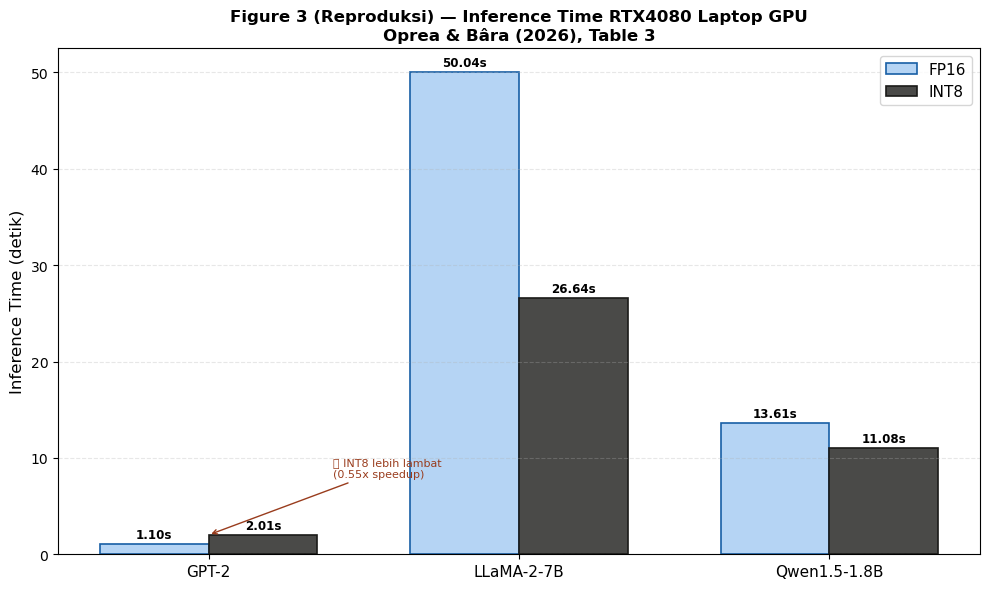

[OK] Disimpan: outputs/figures/fig3_rtx4080_inference.png


In [4]:
df80    = df[df.GPU == 'RTX4080']
fp16_80 = [df80[(df80.Model==m)&(df80.Precision=='FP16')]['Time_s'].values[0] for m in models]
int8_80 = [df80[(df80.Model==m)&(df80.Precision=='INT8')]['Time_s'].values[0] for m in models]

fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x-w/2, fp16_80, w, label='FP16', color='#B5D4F4', edgecolor='#185FA5', lw=1.2)
b2 = ax.bar(x+w/2, int8_80, w, label='INT8', color='#4A4A48', edgecolor='#1A1A18', lw=1.2)

for bar in list(b1)+list(b2):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.3, f'{h:.2f}s',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Inference Time (detik)', fontsize=12)
ax.set_title('Figure 3 (Reproduksi) — Inference Time RTX4080 Laptop GPU\n'
             'Oprea & Bâra (2026), Table 3', fontsize=12, fontweight='bold')
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.annotate('🔴 INT8 lebih lambat\n(0.55x speedup)',
            xy=(0, 2.01), xytext=(0.4, 8),
            fontsize=8, color='#993C1D',
            arrowprops=dict(arrowstyle='->', color='#993C1D'))
plt.tight_layout()
plt.savefig(FIGURES/'fig3_rtx4080_inference.png', dpi=150, bbox_inches='tight')
plt.show()
print("[OK] Disimpan: outputs/figures/fig3_rtx4080_inference.png")

## 4. Throughput comparison (tok/s)

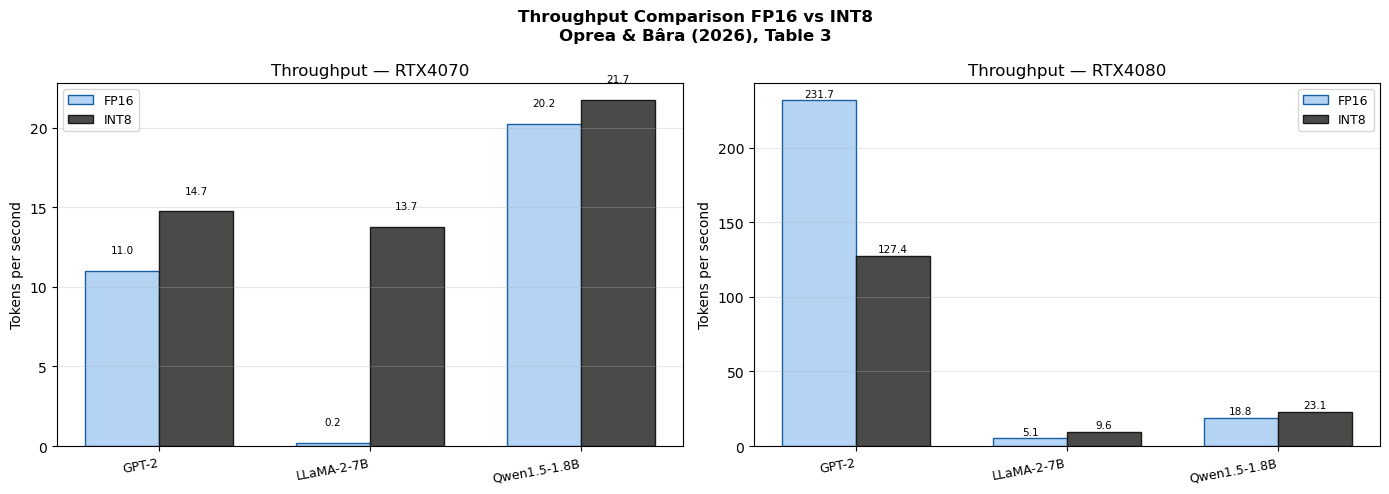

[OK] Disimpan: outputs/figures/throughput_comparison.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, gpu, df_gpu in [(axes[0],'RTX4070',df70),(axes[1],'RTX4080',df80)]:
    fp16_t = [df_gpu[(df_gpu.Model==m)&(df_gpu.Precision=='FP16')]['Tokens_per_s'].values[0] for m in models]
    int8_t = [df_gpu[(df_gpu.Model==m)&(df_gpu.Precision=='INT8')]['Tokens_per_s'].values[0] for m in models]
    b1 = ax.bar(x-w/2, fp16_t, w, label='FP16', color='#B5D4F4', edgecolor='#185FA5', lw=1)
    b2 = ax.bar(x+w/2, int8_t, w, label='INT8', color='#4A4A48', edgecolor='#1A1A18', lw=1)
    for bar in list(b1)+list(b2):
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+1, f'{h:.1f}',
                ha='center', va='bottom', fontsize=7.5)
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=10, ha='right', fontsize=9)
    ax.set_ylabel('Tokens per second'); ax.set_title(f'Throughput — {gpu}')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Throughput Comparison FP16 vs INT8\nOprea & Bâra (2026), Table 3',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES/'throughput_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("[OK] Disimpan: outputs/figures/throughput_comparison.png")

## 5. Sample output dari jurnal (Appendix A)

In [7]:
app = pd.read_csv('../dataset/appendixA_sample_outputs.csv')
print("=== APPENDIX A: Sample Output Text (dari jurnal) ===\n")
for _, row in app.iterrows():
    print(f"[{row.GPU}] {row.Model} — {row.Precision} | {row.Time_s}s")
    print(f'  "{str(row.Sample_Output)[:200]}"')
    print()

=== APPENDIX A: Sample Output Text (dari jurnal) ===

[RTX4070] GPT-2 — FP16 | 23.21s
  "In the future, quantization for large language models will be a major focus of the future. The goal of this paper is to provide a framework for the development of a language model that can be used to "

[RTX4070] GPT-2 — INT8 | 17.37s
  "In the future, quantization for large language models will!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!"

[RTX4080] GPT-2 — FP16 | 1.1s
  "In the future, quantization for large language models will be a major focus of the future. The goal of this paper is to provide a framework for the development of a language model that can be used to "

[RTX4080] GPT-2 — INT8 | 2.01s
  "In the future, quantization for large language models will be a major focus of the research. The goal of this paper is to provide a framework for the development of a language model that can be used t"

[RTX4070]